# Python Data Visualization Use Case Examples

### 1. Import Required Packages

We first include a cell to import all the packages we'll be using for these examples.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as lsc

import numpy as np
import pandas as pd

import os

### 2. Set Up Visual Parameters

Here, we can clearly lay out variables to represent aspects of our figure that we may want to edit frequently until we find the best fit for our needs. This can also be useful for easily generating the same or similar figure reformatted for different media types; for example, tweaking a figure to fit a large poster instead of a small publication-ready form factor.

We use matplotlib's native color palette to define the colors used in the following example heatmaps. Some colors are easily defined by a common word that can be passed to the cmap argument as a string. Documentation on the full extent of color names can be found [here.](https://matplotlib.org/stable/gallery/color/named_colors.html)

In [18]:
title = 'Viral Spike Protein Glycan Residue Depths'
title_fontsize = 20

xlabel = 'Residue Position in Glycan Chain'
xlabel_fontsize = 16

ylabel = 'Glycan Chain ID'
ylabel_fontsize = 16

legend_title = r'Distance From Protein Surface ($\AA$)'
legend_fontsize = 16

# You can try other colors using common English color names:
buried_color = 'darkred'            # Try 'purple', 'hotpink', or 'sienna'
surface_color = 'white'
exposed_color = 'darkblue'          # Try 'darkorange', 'lime', or 'deepskyblue'

figure_width_inches = 15
figure_height_inches = 10

### 3. Example Plot of a Single Heatmap

Running the following code should output a single heatmap with the parameters we specified in Part 2 directly under the code cell. To update this figure with different visual parameters, you will need to edit and rerun the Part 2 code cell before running this code cell.

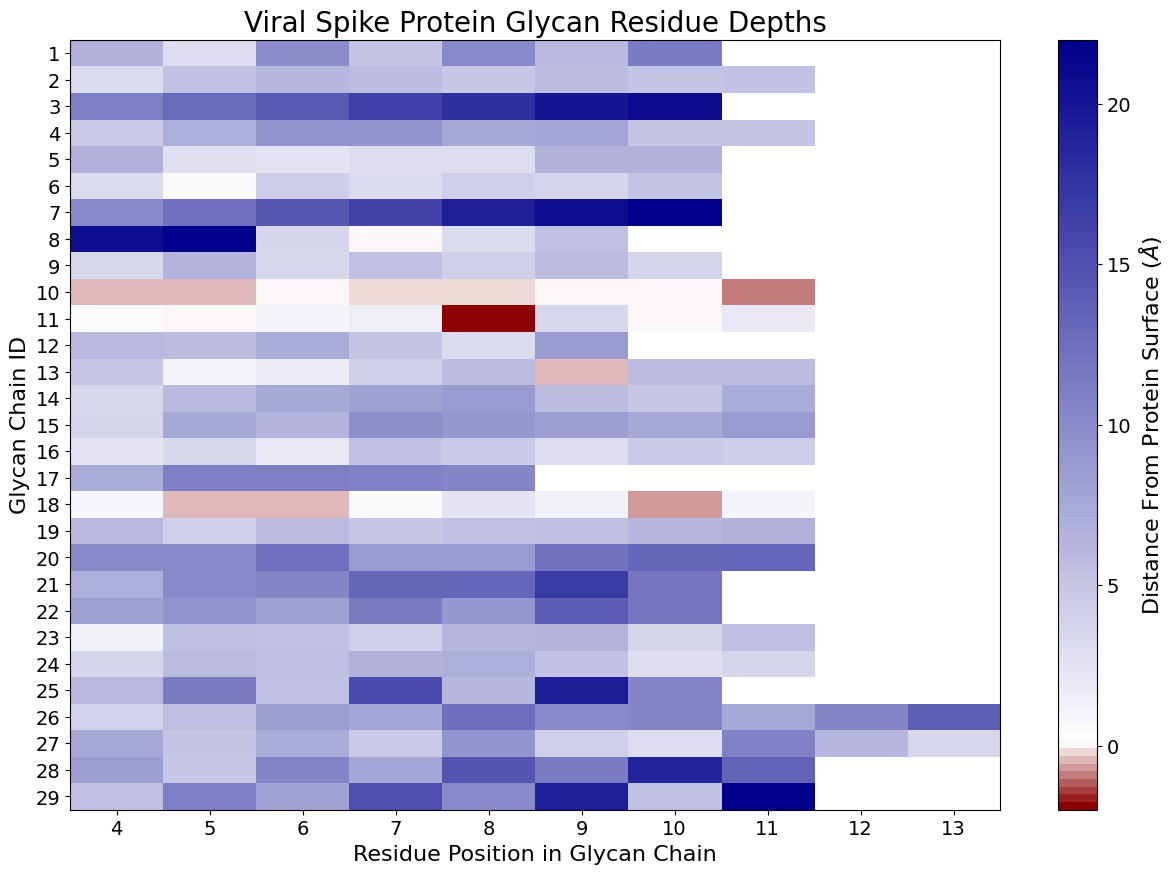

In [ ]:
data_filename = 'single_hmap_data.csv'

df = pd.read_csv(data_filename)

df.drop('Unnamed: 0', axis=1, inplace=True)
df.columns = [4,5,6,7,8,9,10,11,12,13]
df.index = list(range(1,30))

vmin = round(df.min().min())
vmax = round(df.max().max())

cmap = lsc.from_list('custom', [
    (0, buried_color),
    ((-vmin/(-vmin+vmax)), surface_color),
    (1, exposed_color),
], N=100)

fig, ax = plt.subplots()
ax = plt.imshow(df, cmap=cmap, interpolation='nearest',
                vmin=vmin, vmax=vmax, aspect='auto',
                extent=[0, len(df.columns), len(df.index), 0])

plt.xticks(np.arange(len(df.columns)) + 0.5, labels=df.columns, fontsize=14)
plt.yticks(np.arange(len(df.index)) + 0.5, labels=df.index, fontsize=14)

plt.xlabel(xlabel, fontsize=xlabel_fontsize)
plt.ylabel(ylabel, fontsize=ylabel_fontsize)

plt.title(title, fontsize=title_fontsize)

fig.set_size_inches(figure_width_inches, figure_height_inches)

cbar = plt.colorbar(ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label(legend_title, fontsize=legend_fontsize)

We can choose to save this figure directly by clicking the "Save As" icon at the top right of the output image, or we can run the following code cell to save the figure to the current directory automatically.

The advantage of saving the figure through the code cell is the ability to specify resolution via the "dpi" argument. A Dots Per Inch (DPI) value of 300 or more is a good standard for outputting publication-quality figures.

In [22]:
fig.savefig('example_hmap_single.png', dpi=300, bbox_inches='tight')

### 4. Example Combined Plot of Three Heatmaps

Running the following code should output three comparable heatmaps on the same figure with the parameters we specified in Part 2 directly under the code cell. Again, to update this figure with different visual parameters, you will need to edit and rerun the Part 2 code cell before running this code cell.

Text(0.5, 0.98, 'Viral Spike Protein Glycan Residue Depths')

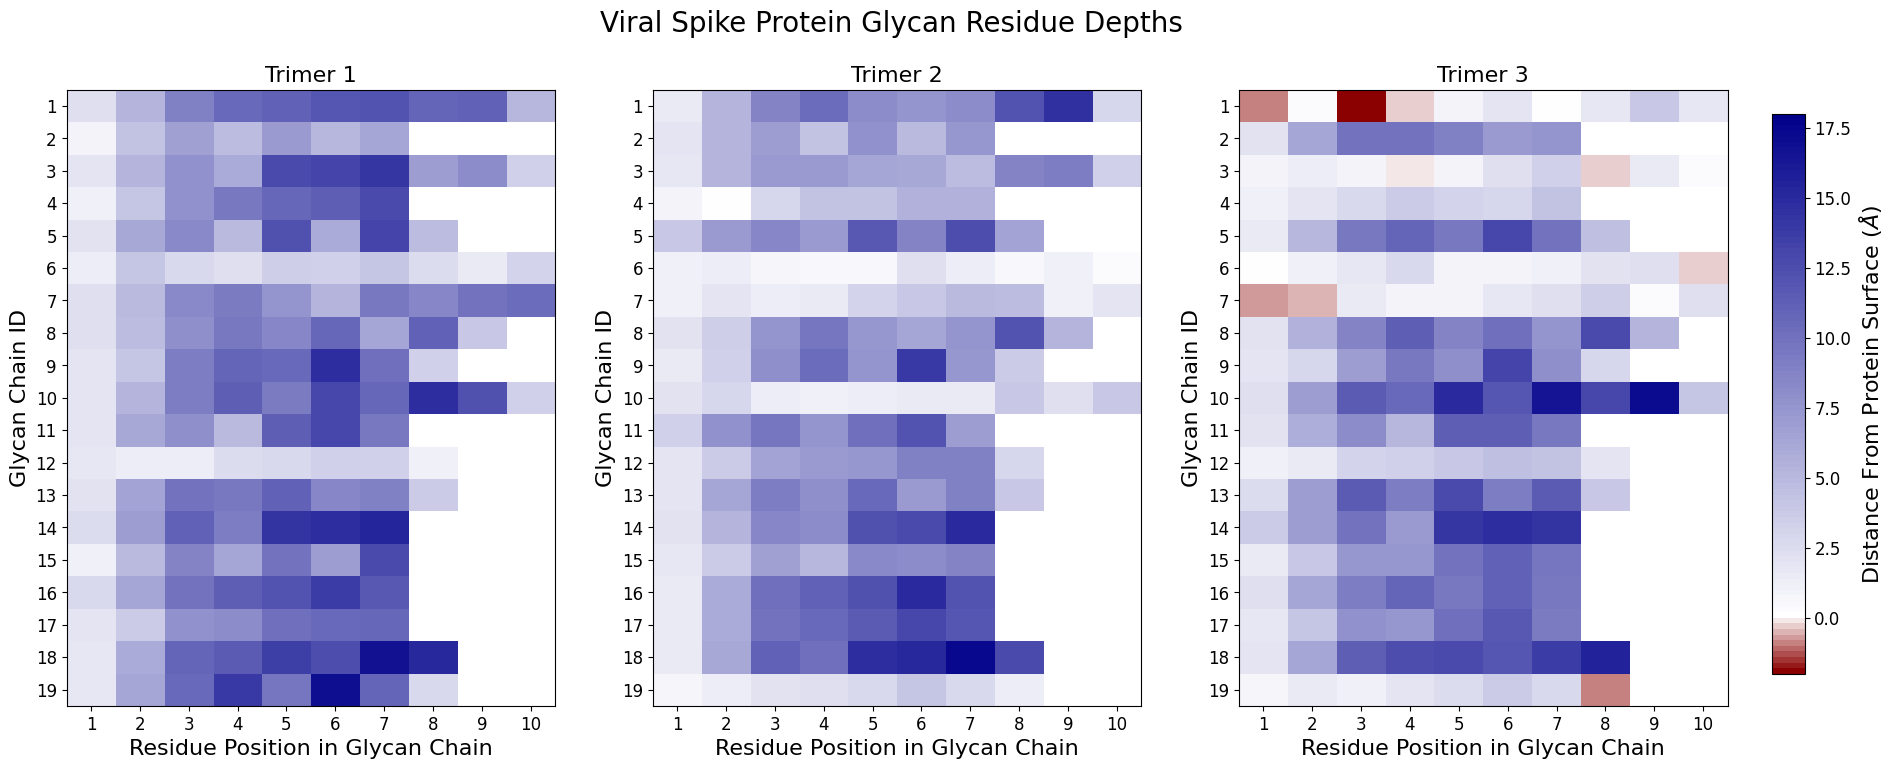

In [ ]:
hmap_1_csv = 'triple_hmap_data_1.csv'
hmap_2_csv = 'triple_hmap_data_2.csv'
hmap_3_csv = 'triple_hmap_data_3.csv'

df_1 = pd.read_csv(hmap_1_csv, index_col=0)
df_2 = pd.read_csv(hmap_2_csv, index_col=0)
df_3 = pd.read_csv(hmap_3_csv, index_col=0)

df_1_data = df_1.values
df_2_data = df_2.values
df_3_data = df_3.values

num_glycans = df_1_data.shape[0]
max_chain_length = df_1_data.shape[1]

start_res_col = 0

all_data = np.concatenate([df_1_data[:, start_res_col:].flatten(),
                           df_2_data[:, start_res_col:].flatten(),
                           df_3_data[:, start_res_col:].flatten()])

all_data = all_data[~np.isnan(all_data)]

vmin = np.floor(np.min(all_data))
vmax = np.ceil(np.max(all_data))

cmap = lsc.from_list('custom', [
    (0, buried_color),
    ((-vmin/(-vmin+vmax)), surface_color),
    (1, exposed_color)
], N=100)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

trimers = [
    ('Trimer 1', df_1_data),
    ('Trimer 2', df_2_data),
    ('Trimer 3', df_3_data)
]

for ax, (trimer_name, data) in zip(axes, trimers):

    plot_data = data[:, start_res_col:]

    im = ax.imshow(plot_data, cmap=cmap, interpolation='nearest',
                   vmin=vmin, vmax=vmax, aspect='auto',
                   extent=[start_res_col+1, max_chain_length+1, num_glycans, 0])
    
    ax.set_xticks(np.arange(start_res_col+1, max_chain_length+1) + 0.5)
    ax.set_xticklabels(range(start_res_col+1, max_chain_length+1), fontsize=12)
    ax.set_yticks(np.arange(num_glycans) + 0.5)
    ax.set_yticklabels(range(1, num_glycans+1), fontsize=12)

    ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    ax.set_ylabel(ylabel, fontsize=ylabel_fontsize)
    ax.set_title(f'{trimer_name}', fontsize=16)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.9, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(legend_title, fontsize=legend_fontsize)

if vmin < 0:
    buried_ticks = np.linspace(vmin, 0, 5)
    exposed_ticks = np.linspace(0, vmax, 4)[1:]
    tick_values = np.concatenate([buried_ticks, exposed_ticks])
else:
    tick_values = np.linspace(vmin, vmax, 8)

fig.suptitle(title, fontsize=title_fontsize, y=0.98)

We can again either save the figure through the notebook or through the following code cell:

In [23]:
fig.savefig('example_hmap_triple.png', dpi=300, bbox_inches='tight')

Example data provided by:

- de Paiva Froes Rocha, R., Tomris, I., Bowman, C.A. et al. All data can be found [here.](https://doi.org/10.1038/s41467-025-66375-7)
- Glycan Accessibility Computational Infrastructure for Ensemble Research (GLACIER) pipeline provided by the SimBioSys Lab at Northeastern University. Example output can be found [here.](https://glacierstorage01.blob.core.windows.net/glacier/16c293c8-6e03-456d-9154-4e410d4a8a4a/index.html)